
----

# 🤖 **`Machine Learning Development Life Cycle (MLDLC) for Data Science`** 📊  

The **Machine Learning Development Life Cycle (MLDLC)** is a structured process that guides **Data Scientists** and **ML Engineers** through each stage of building, deploying, and maintaining **Machine Learning (ML)** models.  

A well-defined MLDLC ensures that models are **accurate**, **scalable**, **ethical**, and **aligned with business goals**.  

---

## 🧭 **Stages of the Machine Learning Development Life Cycle:**  
1. **Problem Definition** 🧠  
2. **Data Collection** 📥  
3. **Data Preparation & Preprocessing** 🧹  
4. **Exploratory Data Analysis (EDA)** 📊  
5. **Feature Engineering & Selection** 🛠️  
6. **Model Selection & Training** 🤖  
7. **Model Evaluation** 📈  
8. **Hyperparameter Tuning** 🎛️  
9. **Model Deployment** 🚀  
10. **Model Monitoring & Maintenance** 📡  

Let’s dive into each stage! 💡  

---

# 🧠 **1. Problem Definition**  

### ✅ **Objective:**  
Clearly define the **business problem** and map it to a **Machine Learning task** (classification, regression, clustering, etc.).  

### 📌 **Key Questions:**  
- What is the **goal**? (e.g., Predict churn, detect fraud)  
- What is the **target variable**?  
- Is it a **supervised**, **unsupervised**, or **reinforcement** learning problem?  
- What metrics will define **success**? (e.g., Accuracy, F1-Score, RMSE)  

### 💡 **Example:**  
- **Business Problem:** Reduce customer churn.  
- **ML Task:** **Classification** (Predict whether a customer will churn or not).  
- **Success Metric:** **F1-Score** (to balance precision and recall).  

---

# 📥 **2. Data Collection**  

### ✅ **Objective:**  
Gather **relevant data** from multiple sources for model training and evaluation.  

### 📌 **Data Sources:**  
- **Databases** (SQL, NoSQL)  
- **APIs** (Twitter API, OpenWeatherMap)  
- **Web Scraping** (BeautifulSoup, Scrapy)  
- **Sensor Data/IoT**  
- **Public Datasets** (Kaggle, UCI, Google Dataset Search)  

### 💡 **Tips:**  
- Ensure **data privacy** and **compliance** (e.g., GDPR).  
- Gather **diverse** and **representative** data to avoid bias.  

---

# 🧹 **3. Data Preparation & Preprocessing**  

### ✅ **Objective:**  
Convert raw data into a **clean**, **structured**, and **machine-readable** format.  

### 📌 **Key Steps:**  
- **Handling Missing Values** → Impute, drop, or use domain knowledge.  
- **Outlier Detection** → Use Z-score, IQR, or Isolation Forest.  
- **Encoding Categorical Data** → One-hot encoding, Label encoding.  
- **Scaling/Normalization** → StandardScaler, MinMaxScaler for numerical data.  
- **Text Preprocessing** → Tokenization, stopword removal (for NLP tasks).  

### 💡 **Example (Python - Preprocessing):**  

In [2]:

import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Load Data
df = pd.read_csv(r'E:\Data Science Materials\Codanics\practice_dataset\customer_data.csv')

# Fill missing values for numeric columns
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# One-hot encoding for categorical columns
df = pd.get_dummies(df, columns=['Gender', 'Geography'])

# Feature Scaling
scaler = StandardScaler()
df[['Age', 'Salary']] = scaler.fit_transform(df[['Age', 'Salary']])


---

# 📊 **4. Exploratory Data Analysis (EDA)**  

### ✅ **Objective:**  
Understand data distributions, relationships, and uncover patterns before modeling.  

### 📌 **Key Techniques:**  
- **Statistical Summary:** `.describe()`, `.info()`  
- **Data Visualization:**  
  - **Histograms** → Distribution of data  
  - **Boxplots** → Outliers  
  - **Heatmaps** → Correlation matrix  
  - **Pairplots** → Relationship between variables  

### 💡 **Example (Python - EDA):** 

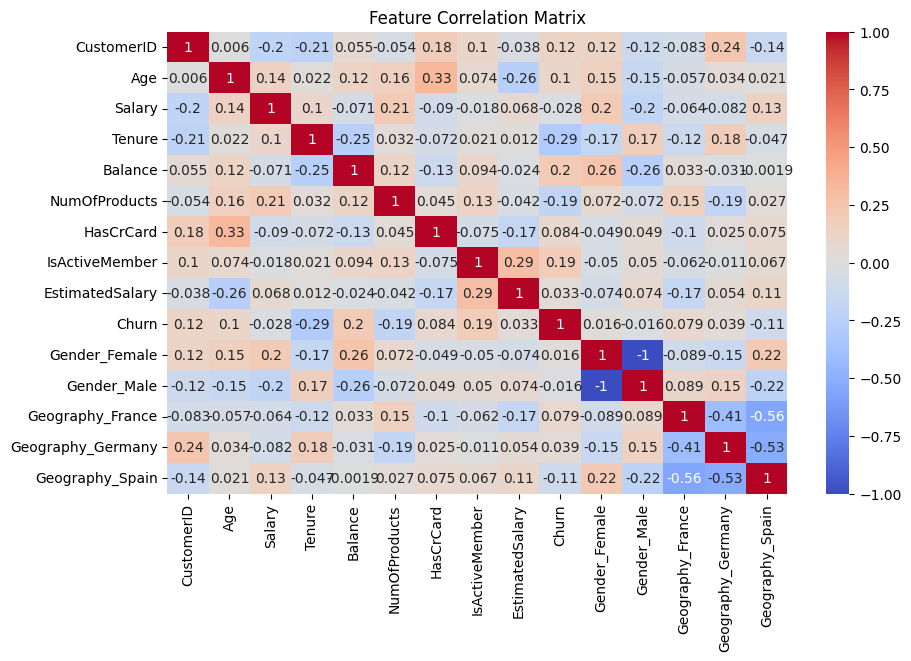

In [3]:

import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


---

# 🛠️ **5. Feature Engineering & Selection**  

### ✅ **Objective:**  
Create new features and select the most **predictive** ones to improve model accuracy.  

### 📌 **Key Techniques:**  
- **Feature Engineering:**  
  - Create interaction terms (e.g., `Price * Quantity`).  
  - Extract features from dates (e.g., day, month, year).  
  - Apply domain-specific knowledge.  
- **Feature Selection:**  
  - **Correlation Matrix** → Remove highly correlated features.  
  - **Recursive Feature Elimination (RFE)**  
  - **Regularization Techniques** → LASSO (L1 penalty)   


---

# 🤖 **6. Model Selection & Training**  

### ✅ **Objective:**  
Choose the right **ML algorithm** and train it on the prepared data.  

### 📌 **Common Algorithms:**  
| **Problem Type**     | **Algorithms**                         |
|---------------------|----------------------------------------|
| **Classification** 🏷️ | Logistic Regression, Random Forest, SVM, XGBoost |
| **Regression** 📈     | Linear Regression, Random Forest Regressor, SVR |
| **Clustering** 🔍     | K-Means, DBSCAN, Hierarchical Clustering |
| **Dimensionality Reduction** 📉 | PCA, t-SNE, UMAP              |

### 💡 **Example (Training a Random Forest):** 

In [4]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Split data
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier()


---


# 📈 **7. Model Evaluation**  

### ✅ **Objective:**  
Evaluate model performance using appropriate metrics and avoid overfitting/underfitting.  

### 📌 **Key Metrics:**  

| **Problem Type**     | **Metrics**                         |
|---------------------|------------------------------------|
| **Classification** 🏷️ | Accuracy, Precision, Recall, F1-Score, ROC-AUC |
| **Regression** 📈     | MSE, RMSE, MAE, R² Score          |
| **Clustering** 🔍     | Silhouette Score, Davies-Bouldin Index |

### 💡 **Example (Evaluating a Classifier):**

In [5]:

from sklearn.metrics import accuracy_score, classification_report

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10




---

# 🎛️ **8. Hyperparameter Tuning**  

### ✅ **Objective:**  
Optimize model performance by fine-tuning hyperparameters.  

### 📌 **Tuning Techniques:**  
- **Grid Search** → Exhaustive search over specified hyperparameters.  
- **Randomized Search** → Random search over hyperparameters.  
- **Bayesian Optimization** → Uses probabilistic models to guide the search.  

### 💡 **Example (Grid Search in Python):** 

In [6]:

from sklearn.model_selection import GridSearchCV

# Define hyperparameters
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30]
}

# Grid Search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'max_depth': 30, 'n_estimators': 50}



---

# 🚀 **9. Model Deployment**  

### ✅ **Objective:**  
Deploy the trained model into a **production environment** to make real-time or batch predictions.  

### 📌 **Deployment Methods:**  
- **APIs** → Use Flask/Django to create REST APIs for model inference.  
- **Cloud Platforms** → AWS SageMaker, Google AI Platform, Azure ML.  
- **Containerization** → Docker + Kubernetes for scalable deployments.  


### 💡 **Example (Flask API for Model Deployment):**  
```python
from flask import Flask, request, jsonify
import pickle

# Load trained model
model = pickle.load(open('rf_model.pkl', 'rb'))

app = Flask(__name__)

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json(force=True)
    prediction = model.predict([list(data.values())])
    return jsonify({'prediction': int(prediction[0])})

if __name__ == '__main__':
    app.run(debug=True)
```


-----

# 📡 **10. Model Monitoring & Maintenance**  

### ✅ **Objective:**  
Continuously monitor model performance and ensure it stays relevant over time.  

### 📌 **Key Activities:**  
- **Track Drift:** Detect **data drift** or **concept drift** where data patterns change.  
- **Monitor KPIs:** Regularly check model performance metrics.  
- **Retrain as Needed:** Schedule retraining when model accuracy drops.  
- **Logging & Alerting:** Set up automated alerts for anomalies in predictions.  

### 💡 **Tools for Monitoring:**  
- **Prometheus + Grafana** → Monitoring & visualization.  
- **MLflow** → Tracking experiments and model versions.  
- **Seldon Core** → Scalable model serving & monitoring.  



---


# 🎯 **Machine Learning Development Life Cycle Cheat Sheet**  

| **Stage**                 | **Key Activities**                           |
|---------------------------|----------------------------------------------|
| **1. Problem Definition**  | Define goals, select ML task, success metric |
| **2. Data Collection**     | Gather data from various sources            |
| **3. Data Preprocessing**  | Clean, transform, and scale data            |
| **4. EDA**                 | Visualize data, detect patterns/anomalies   |
| **5. Feature Engineering** | Create & select meaningful features         |
| **6. Model Training**      | Choose ML algorithm & train the model       |
| **7. Model Evaluation**    | Evaluate using appropriate metrics          |
| **8. Hyperparameter Tuning**| Optimize for best performance             |
| **9. Deployment**          | Deploy model to production                  |
| **10. Monitoring**         | Track, maintain, and retrain as needed      |



---

# 💡 **Final Thoughts:**  

✔ **MLDLC is an iterative process**—refinement and retraining are key.  
✔ **Data quality** is as important as algorithm selection.  
✔ **Monitoring post-deployment** ensures models remain accurate and reliable.  

---